In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r'Crop_Recommendation.csv')

In [3]:
data

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee


In [4]:
data.isnull().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Nitrogen,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
Phosphorus,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
Potassium,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
Temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
Humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
pH_Value,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
Rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
data.describe(include='O')

,Crop
count,2200
unique,22
top,Rice
freq,100


In [8]:
# to know counts of every column in data set

for col in data:
    print(f'number of every item in---> {data[col].value_counts()}')
    print('*'*50)

number of every item in---> 22     44
40     44
27     42
39     41
31     41
       ..
136     2
139     1
135     1
130     1
46      1
Name: Nitrogen, Length: 137, dtype: int64
**************************************************
number of every item in---> 60    56
58    48
56    46
55    44
57    42
      ..
83     2
82     2
90     2
93     1
84     1
Name: Phosphorus, Length: 117, dtype: int64
**************************************************
number of every item in---> 17    90
22    87
15    86
20    80
25    78
      ..
5      8
11     8
13     7
7      5
80     4
Name: Potassium, Length: 73, dtype: int64
**************************************************
number of every item in---> 20.879744    1
29.480699    1
29.943492    1
28.033065    1
29.884305    1
            ..
25.365861    1
28.568406    1
30.284966    1
27.325421    1
23.603016    1
Name: Temperature, Length: 2200, dtype: int64
**************************************************
number of every item in---> 82.002744

AttributeError: Text.set() got an unexpected keyword argument 'fondict'

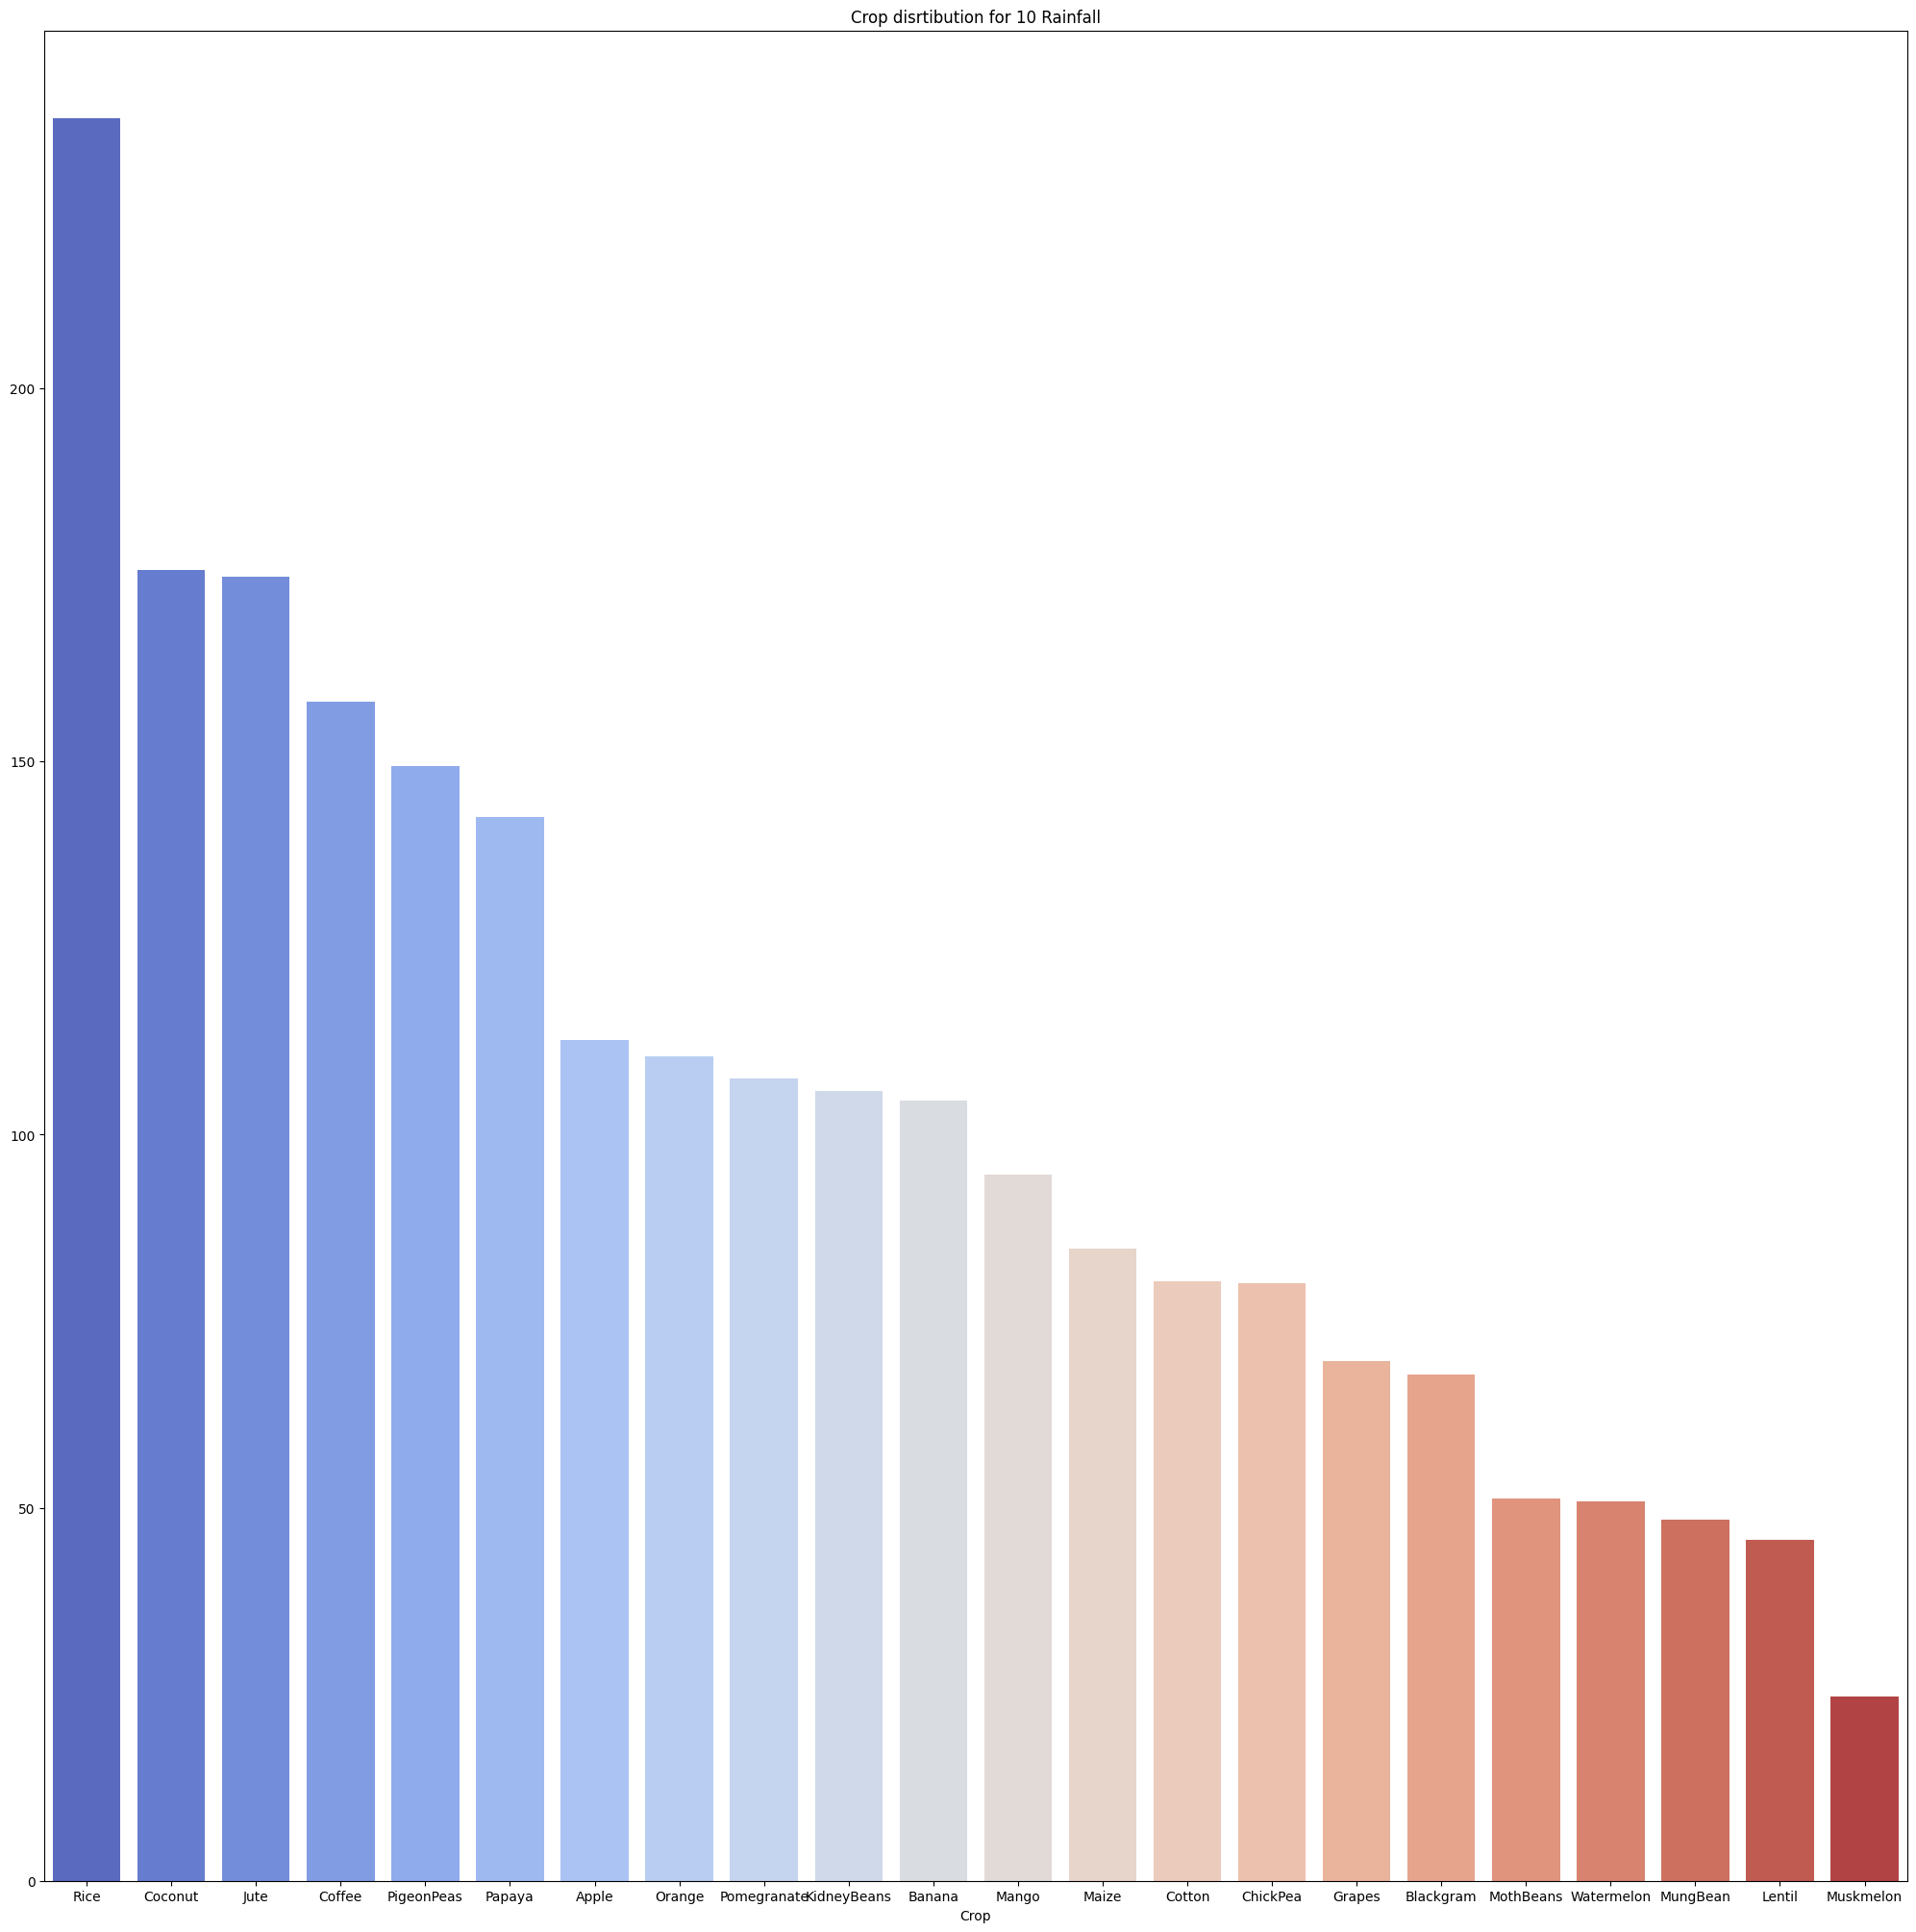

In [9]:
# obserev crop distribution of top 10 rainfall

f =  {'family':'serif','size':50,'color':'r'}

top_10_Rainfall = data.groupby('Crop')['Rainfall'].mean().sort_values(ascending=False)
plt.figure(figsize=(25,25))
sns.barplot(x=top_10_Rainfall.index,y=top_10_Rainfall.values,palette='coolwarm')
plt.title('Crop disrtibution for 10 Rainfall',fondict=f)
plt.xlabel('Crop',fondict=f)
plt.ylabel('Rainfall')

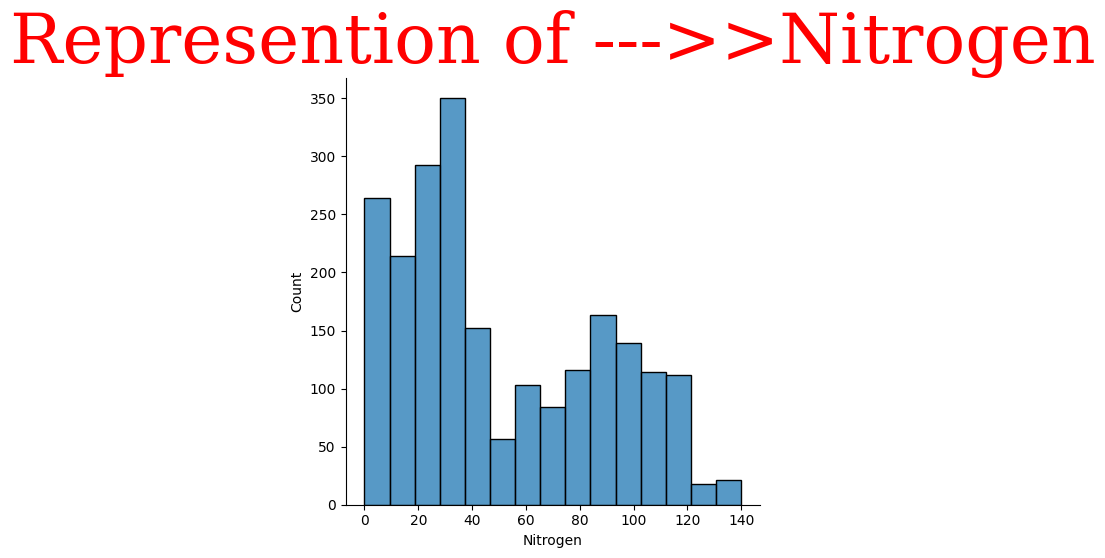

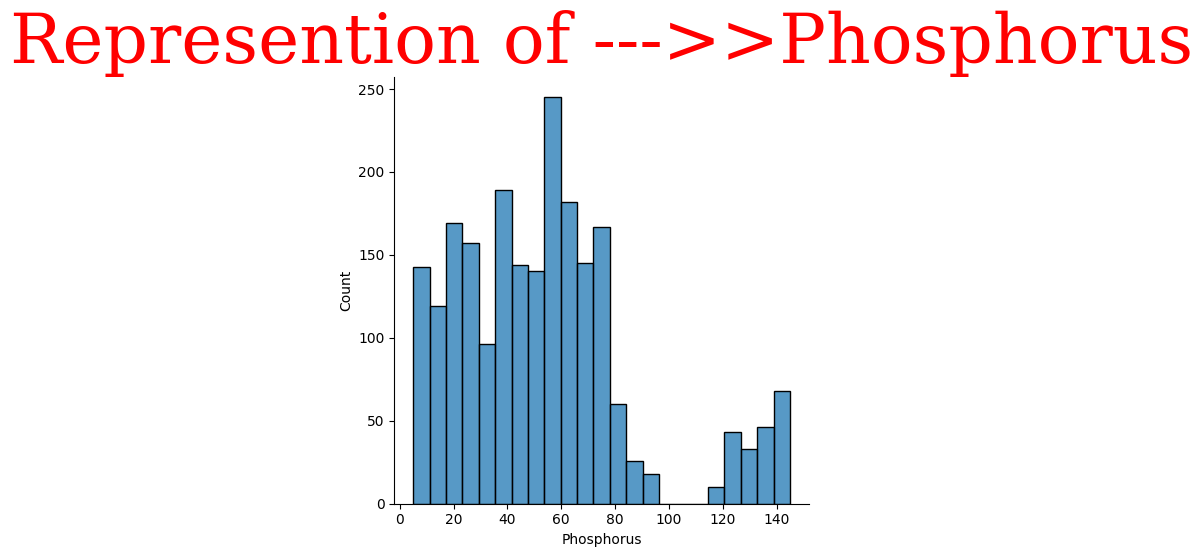

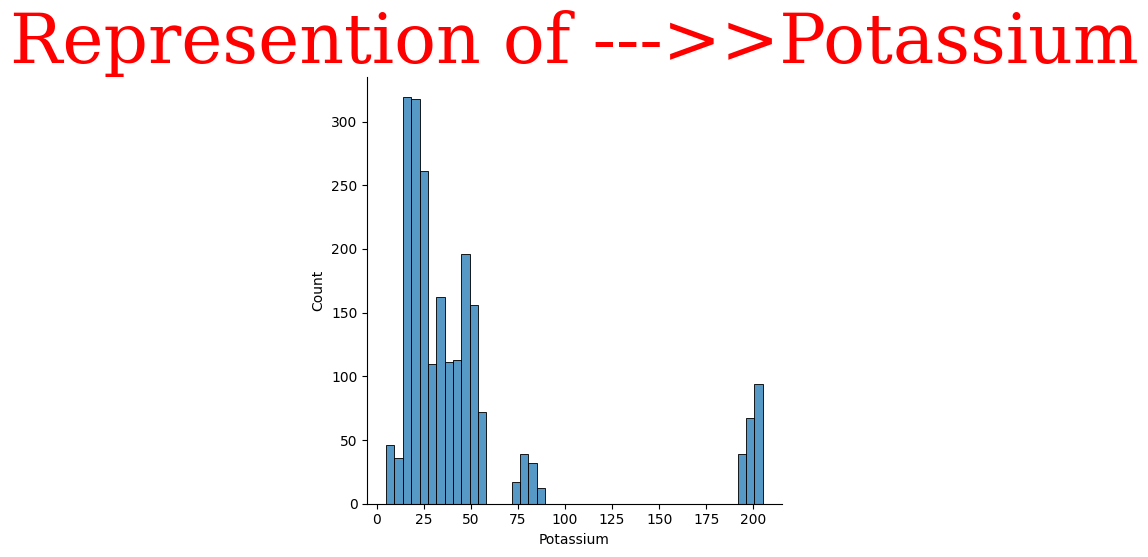

In [10]:
for col in data.select_dtypes(include="int64").columns:
    sns.displot(data[col])
    plt.title("Represention of --->>"+col,fontdict=f)

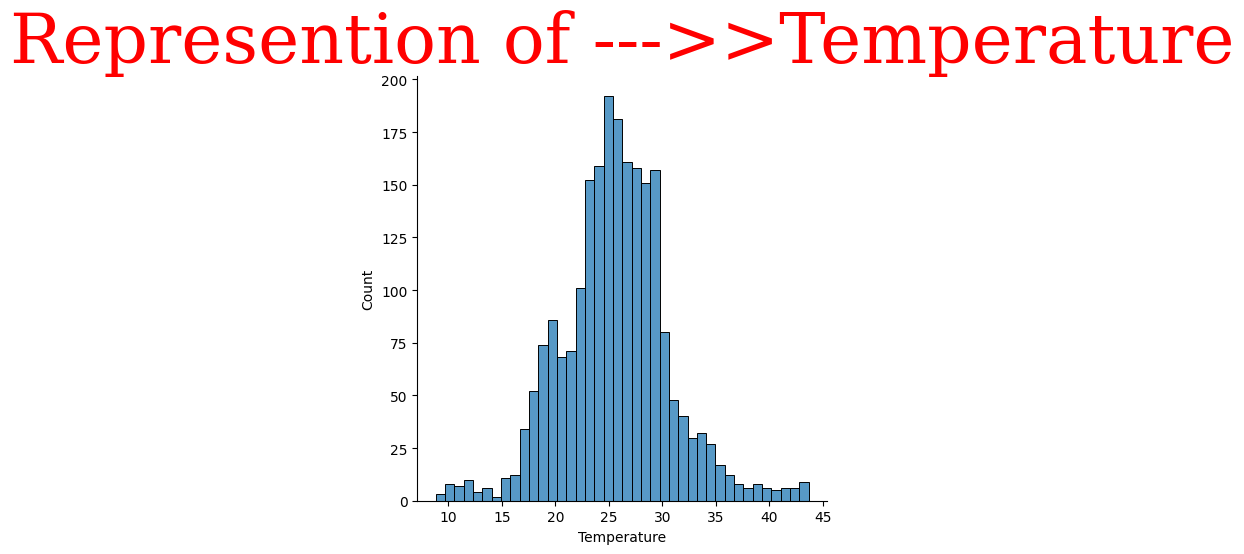

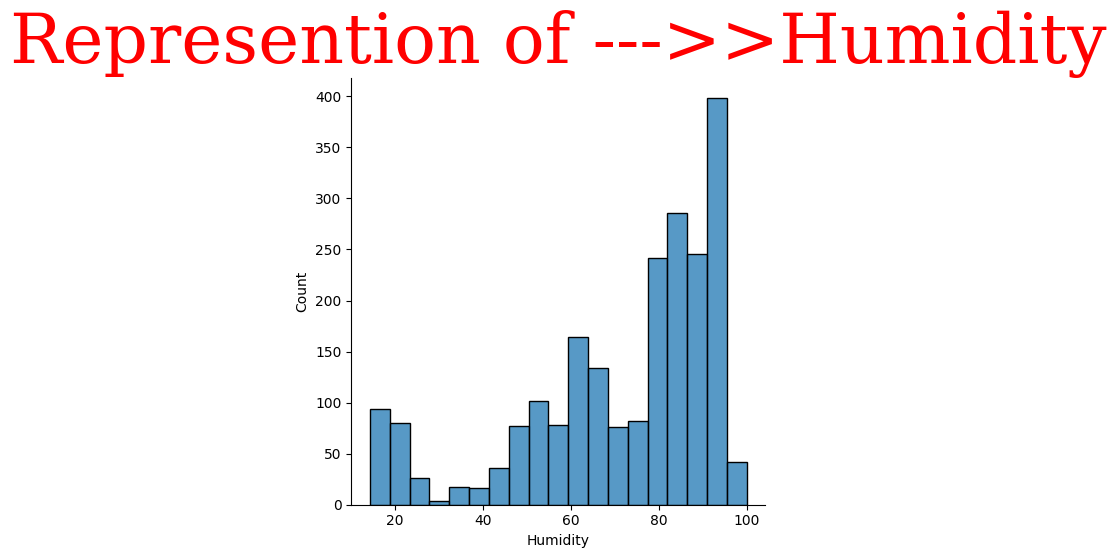

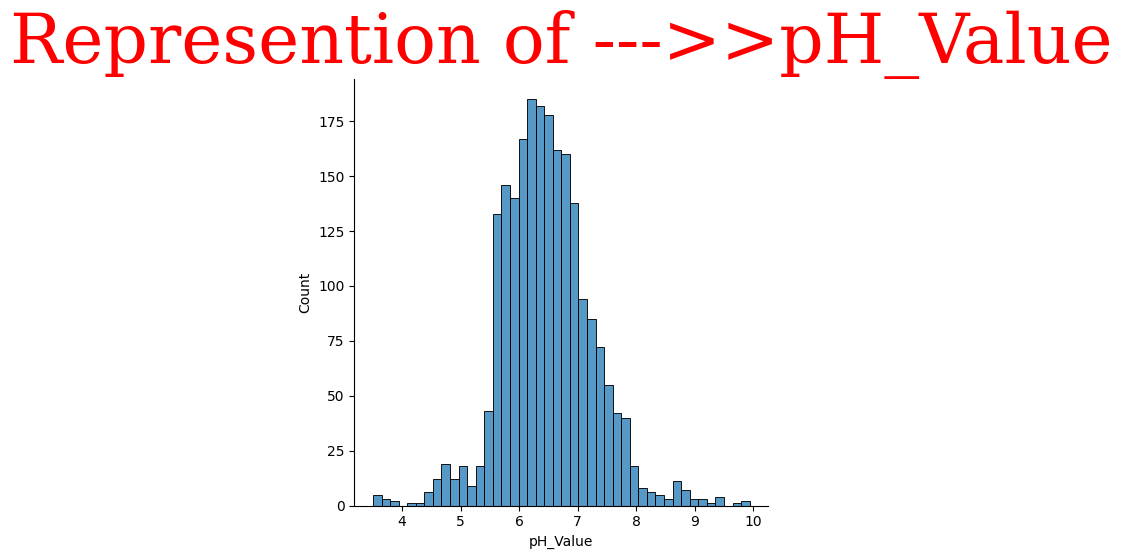

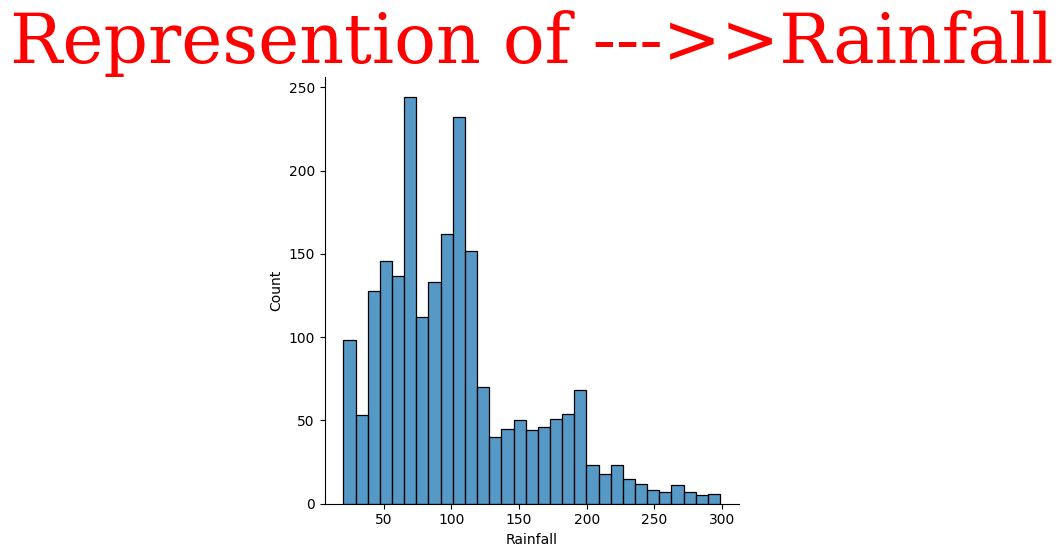

In [11]:
for col in data.select_dtypes(include="float64").columns:
    sns.displot(data[col])
    plt.title("Represention of --->>"+col,fontdict=f)

Text(0.5, 1.0, 'values of PH for every crop')

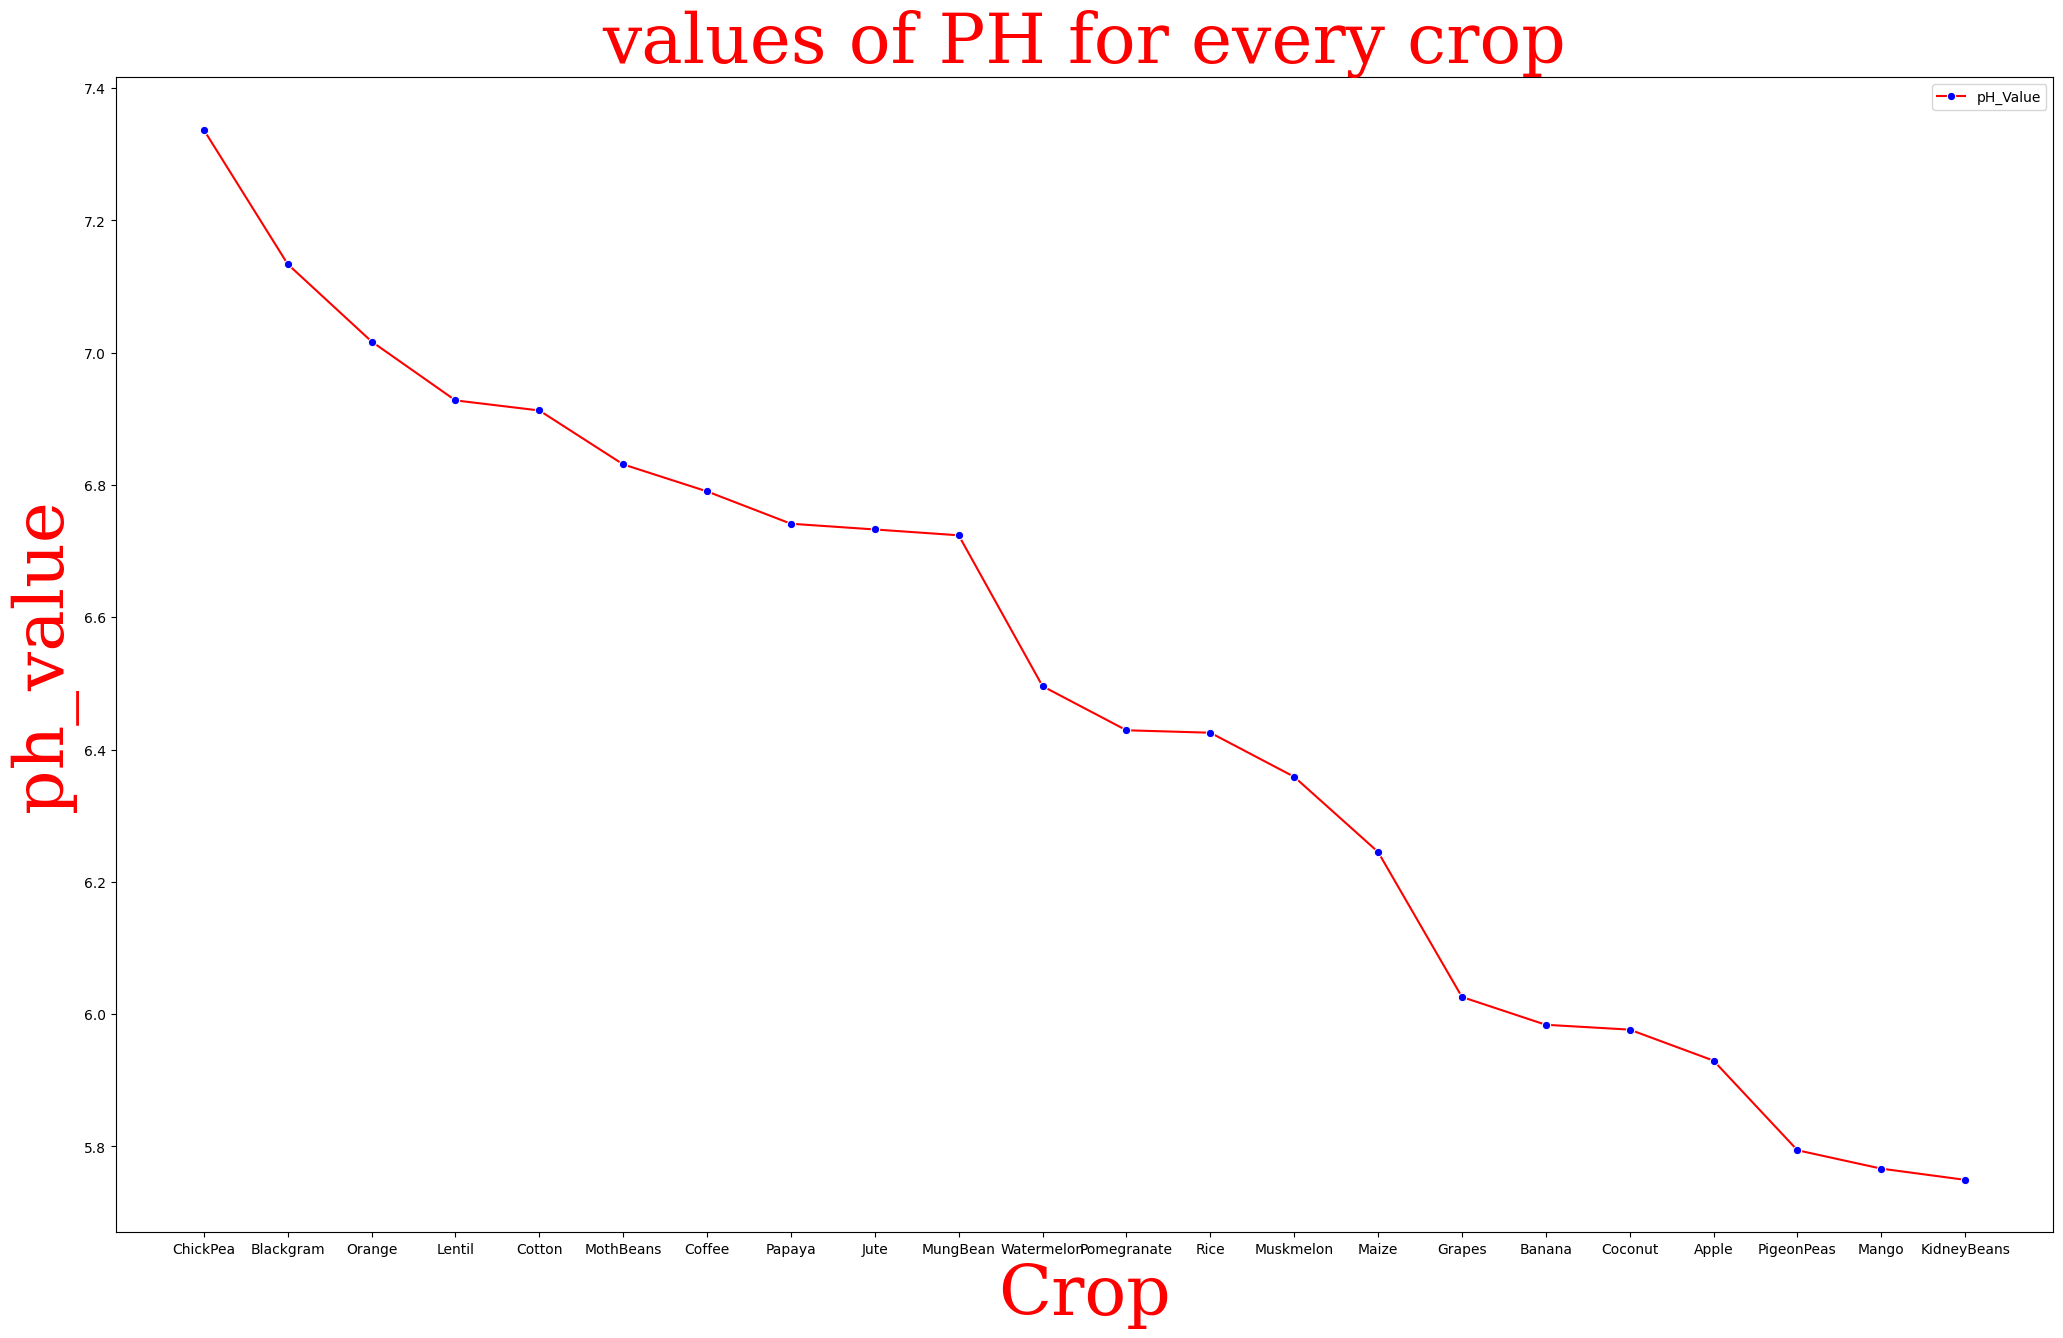

In [12]:
plt.figure(figsize=(25,15))
ph_value = data.groupby('Crop')['pH_Value'].mean().sort_values(ascending=False)
sns.lineplot(x=ph_value.index,y=ph_value.values,marker="o",color="r",mfc="b",label="pH_Value")
plt.xlabel('Crop',fontdict=f)
plt.ylabel('ph_value',fontdict=f)
plt.title('values of PH for every crop',fontdict=f)

<Figure size 7500x4500 with 0 Axes>

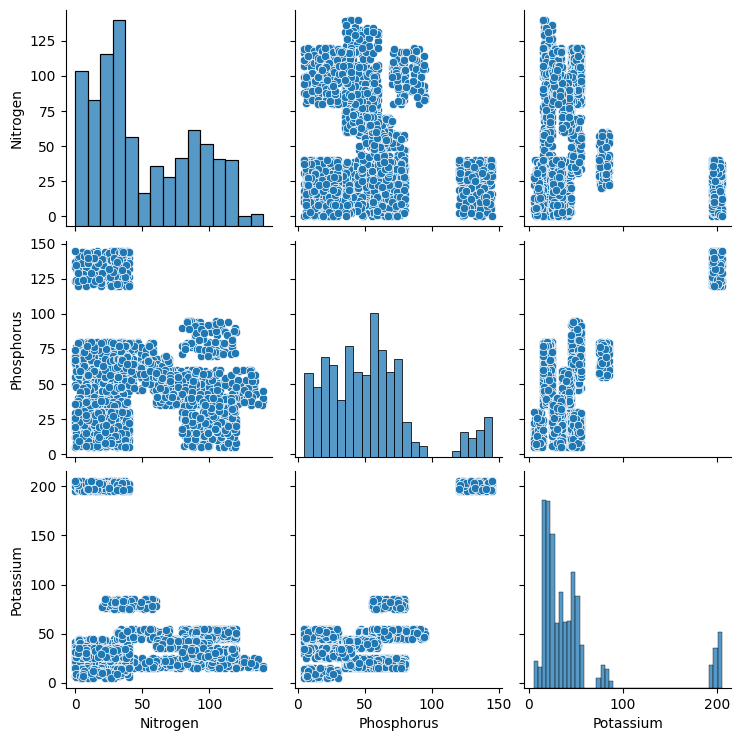

In [13]:
plt.figure(figsize=(25,15),dpi=300)
sns.pairplot(data.select_dtypes(include="int64"))

<Figure size 7500x4500 with 0 Axes>

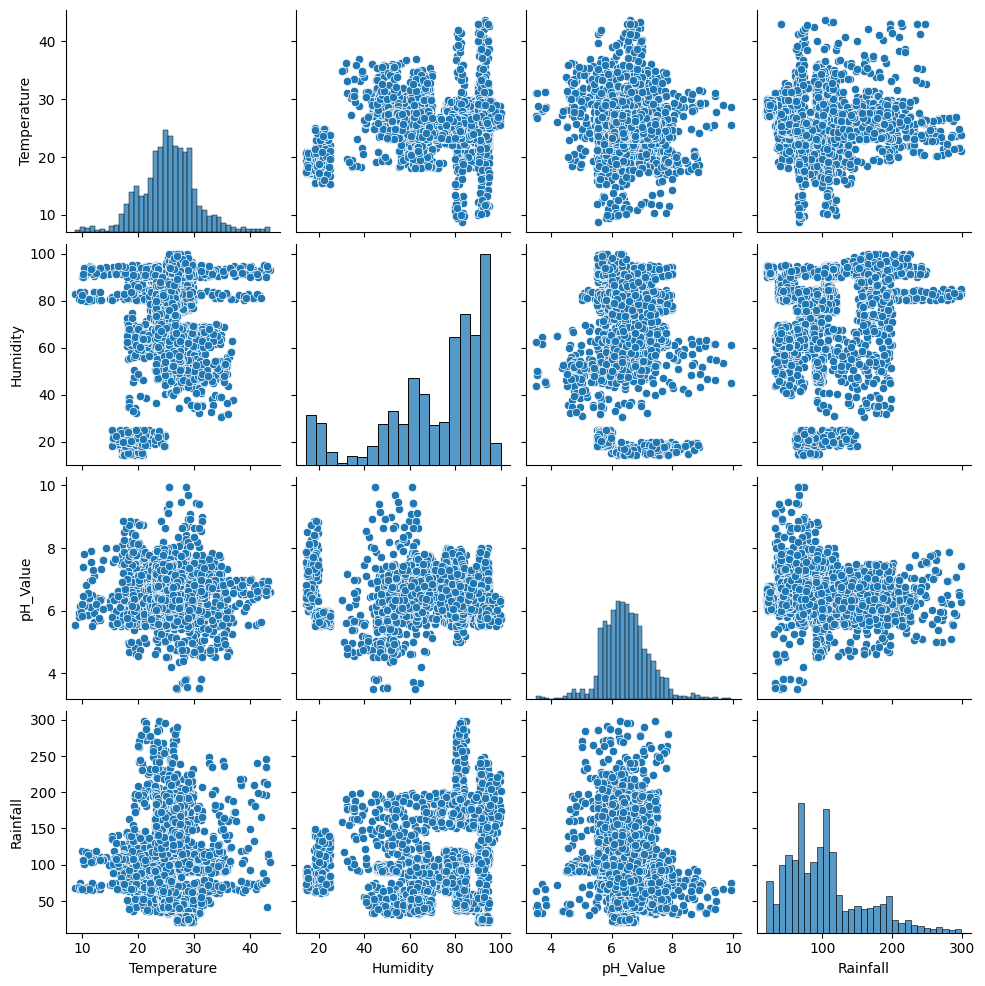

In [14]:
plt.figure(figsize=(25,15),dpi=300)
sns.pairplot(data.select_dtypes(include="float64"))

In [15]:
data['Crop'].unique()


array(['Rice', 'Maize', 'ChickPea', 'KidneyBeans', 'PigeonPeas',
       'MothBeans', 'MungBean', 'Blackgram', 'Lentil', 'Pomegranate',
       'Banana', 'Mango', 'Grapes', 'Watermelon', 'Muskmelon', 'Apple',
       'Orange', 'Papaya', 'Coconut', 'Cotton', 'Jute', 'Coffee'],
      dtype=object)

In [16]:
data['Crop'] = data['Crop'].map({'Rice':0, 'Maize':1, 'ChickPea':2, 'KidneyBeans':3, 'PigeonPeas':4,
       'MothBeans':5, 'MungBean':6, 'Blackgram':7, 'Lentil':8, 'Pomegranate':9,
       'Banana':10, 'Mango':11, 'Grapes':12, 'Watermelon':13, 'Muskmelon':14, 'Apple':15,
       'Orange':17, 'Papaya':18, 'Coconut':19, 'Cotton':20, 'Jute':21, 'Coffee':22})

In [17]:
data

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,0
1,85,58,41,21.770462,80.319644,7.038096,226.655537,0
2,60,55,44,23.004459,82.320763,7.840207,263.964248,0
3,74,35,40,26.491096,80.158363,6.980401,242.864034,0
4,78,42,42,20.130175,81.604873,7.628473,262.717340,0
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,22
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,22
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,22
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,22


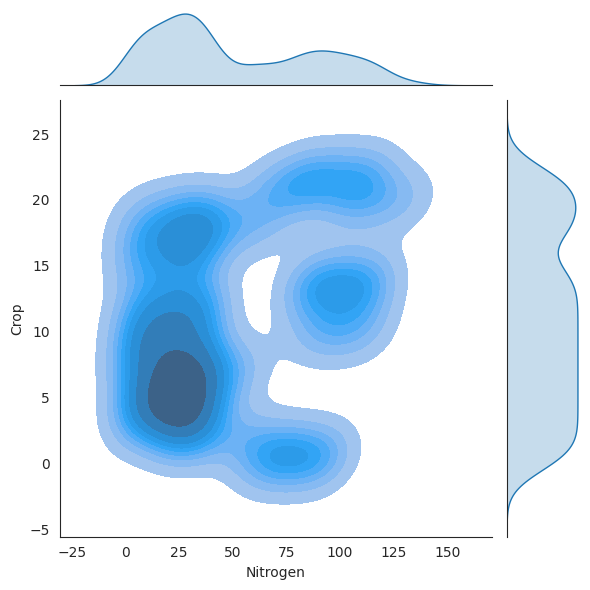

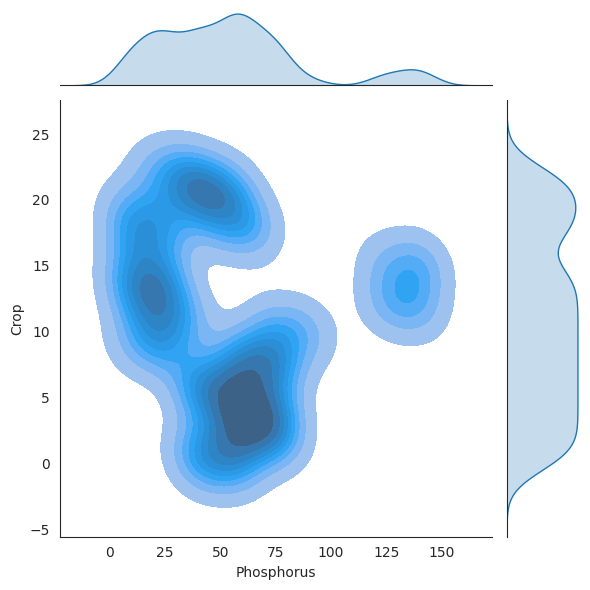

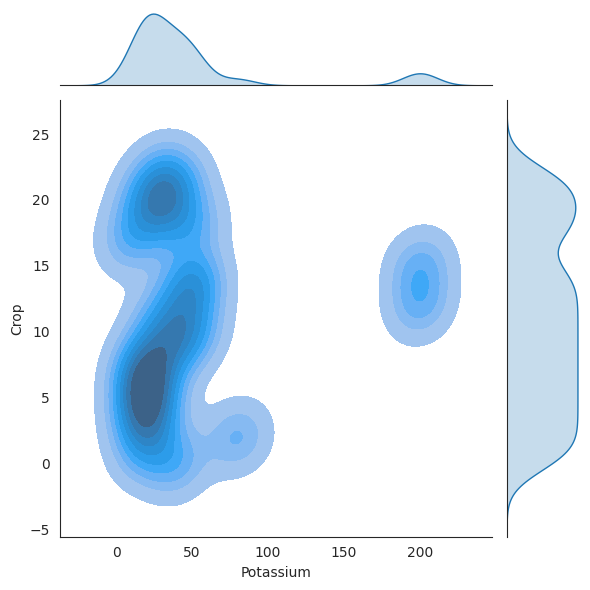

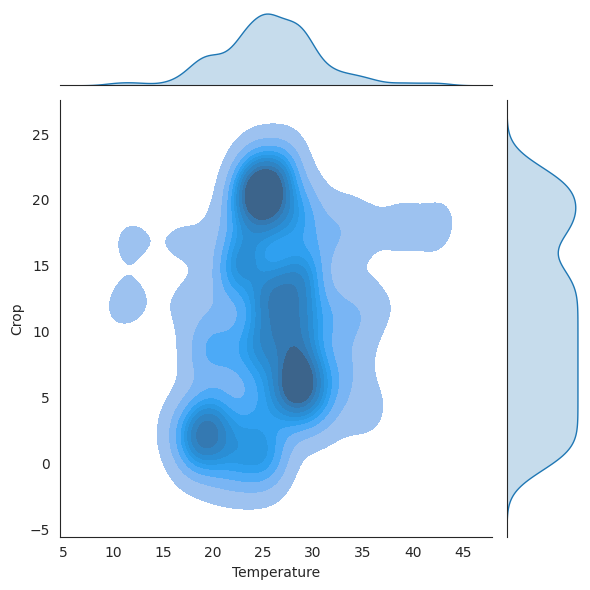

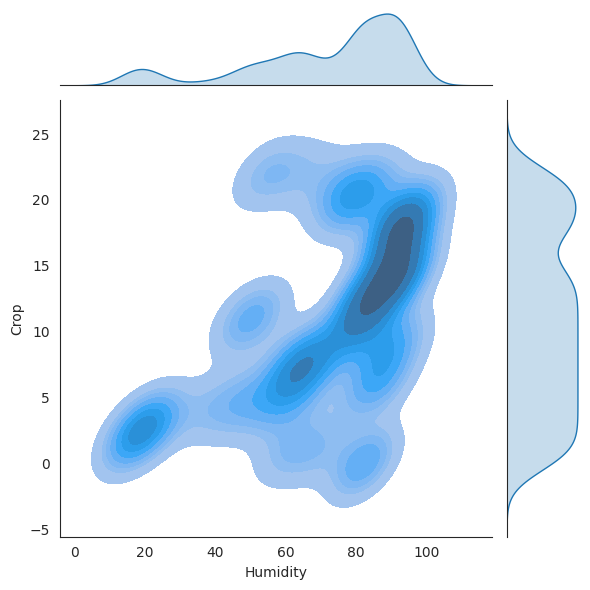

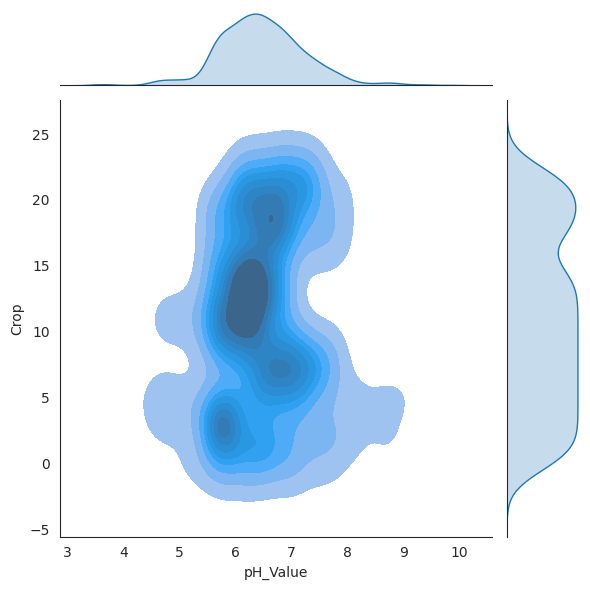

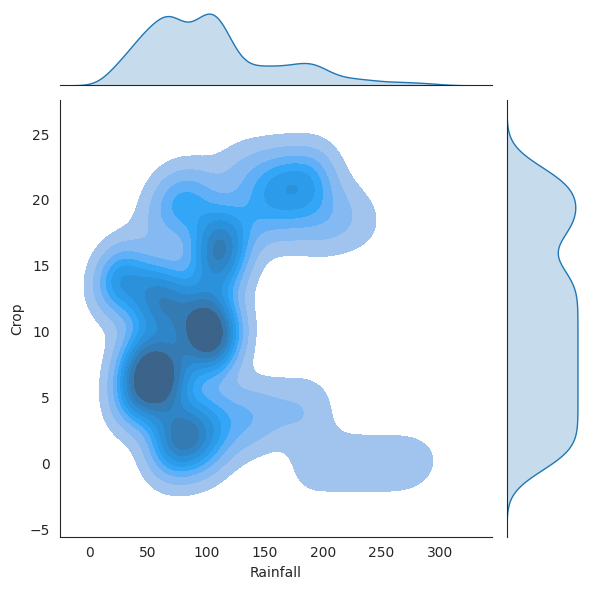

In [18]:
for col in data.select_dtypes("number"):
    if col !="Crop":
      with sns.axes_style("white"):
          sns.jointplot(x=data[col],y=data["Crop"],kind="kde",fill=True)

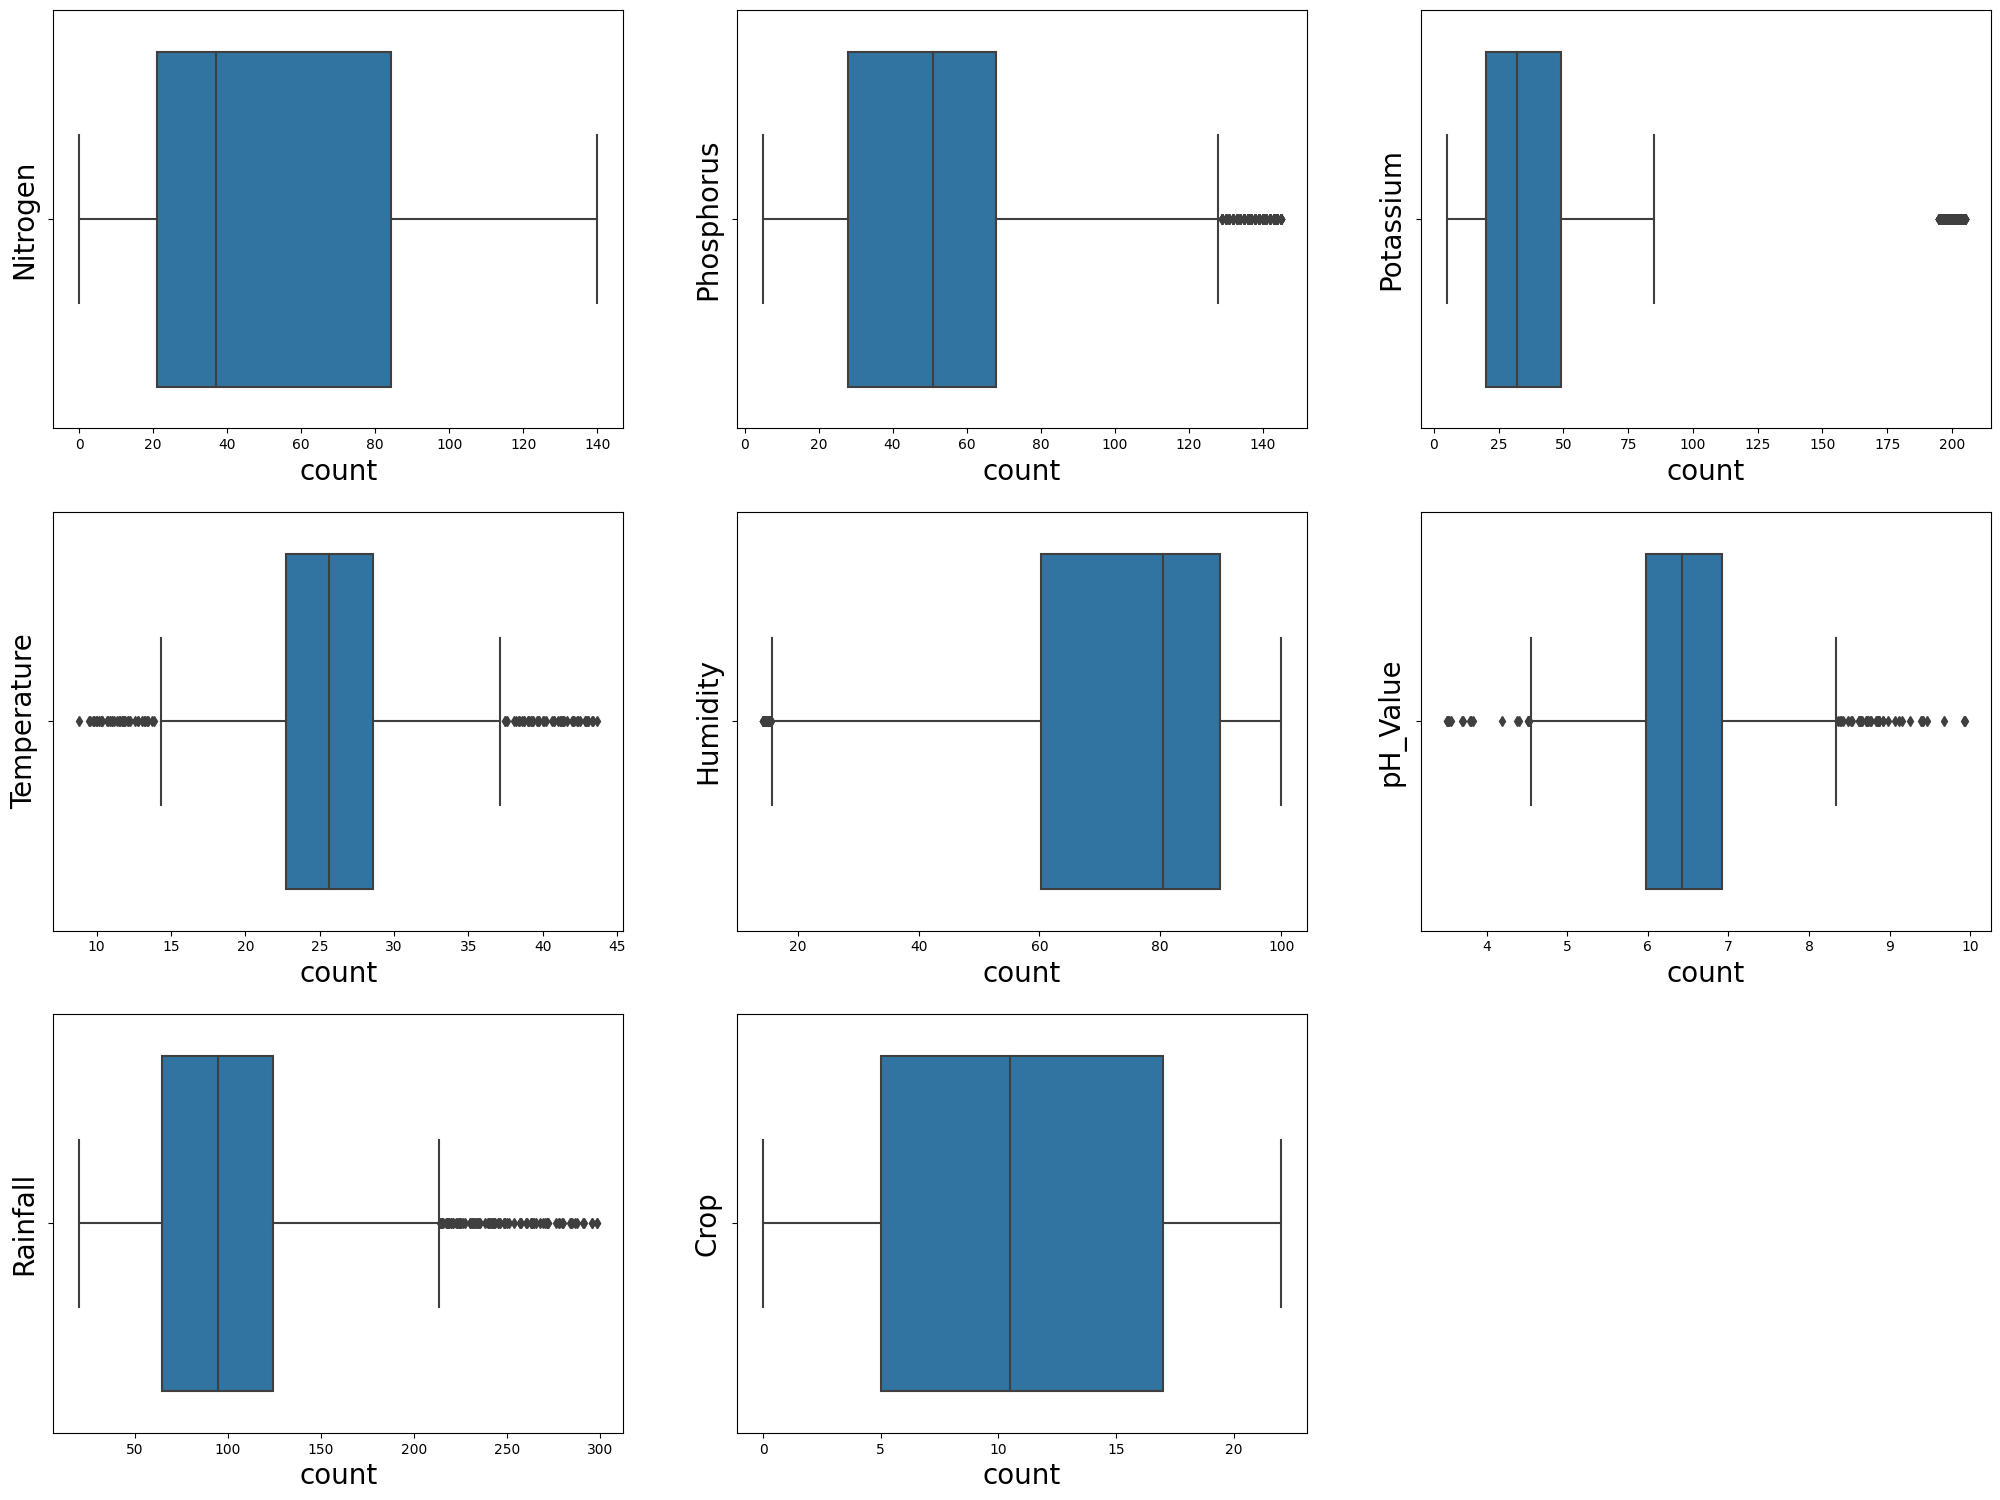

In [19]:
plt.figure(figsize=(25,25),facecolor='white')
pltnumber=1

for col in data:
    if pltnumber<=12:
        ax = plt.subplot(4,3,pltnumber)
        sns.boxplot(x=data[col])
        plt.xlabel('count',fontsize=20)
        plt.ylabel(col,fontsize=20)
    pltnumber+=1
plt.show()

In [20]:
for column in data:
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_limit = Q1 - 1.5*IQR
  upper_limit = Q3 + 1.5*IQR
  data.loc[data[column]<lower_limit,column]=data[column].mean()
  data.loc[data[column]>upper_limit,column]=data[column].mean()

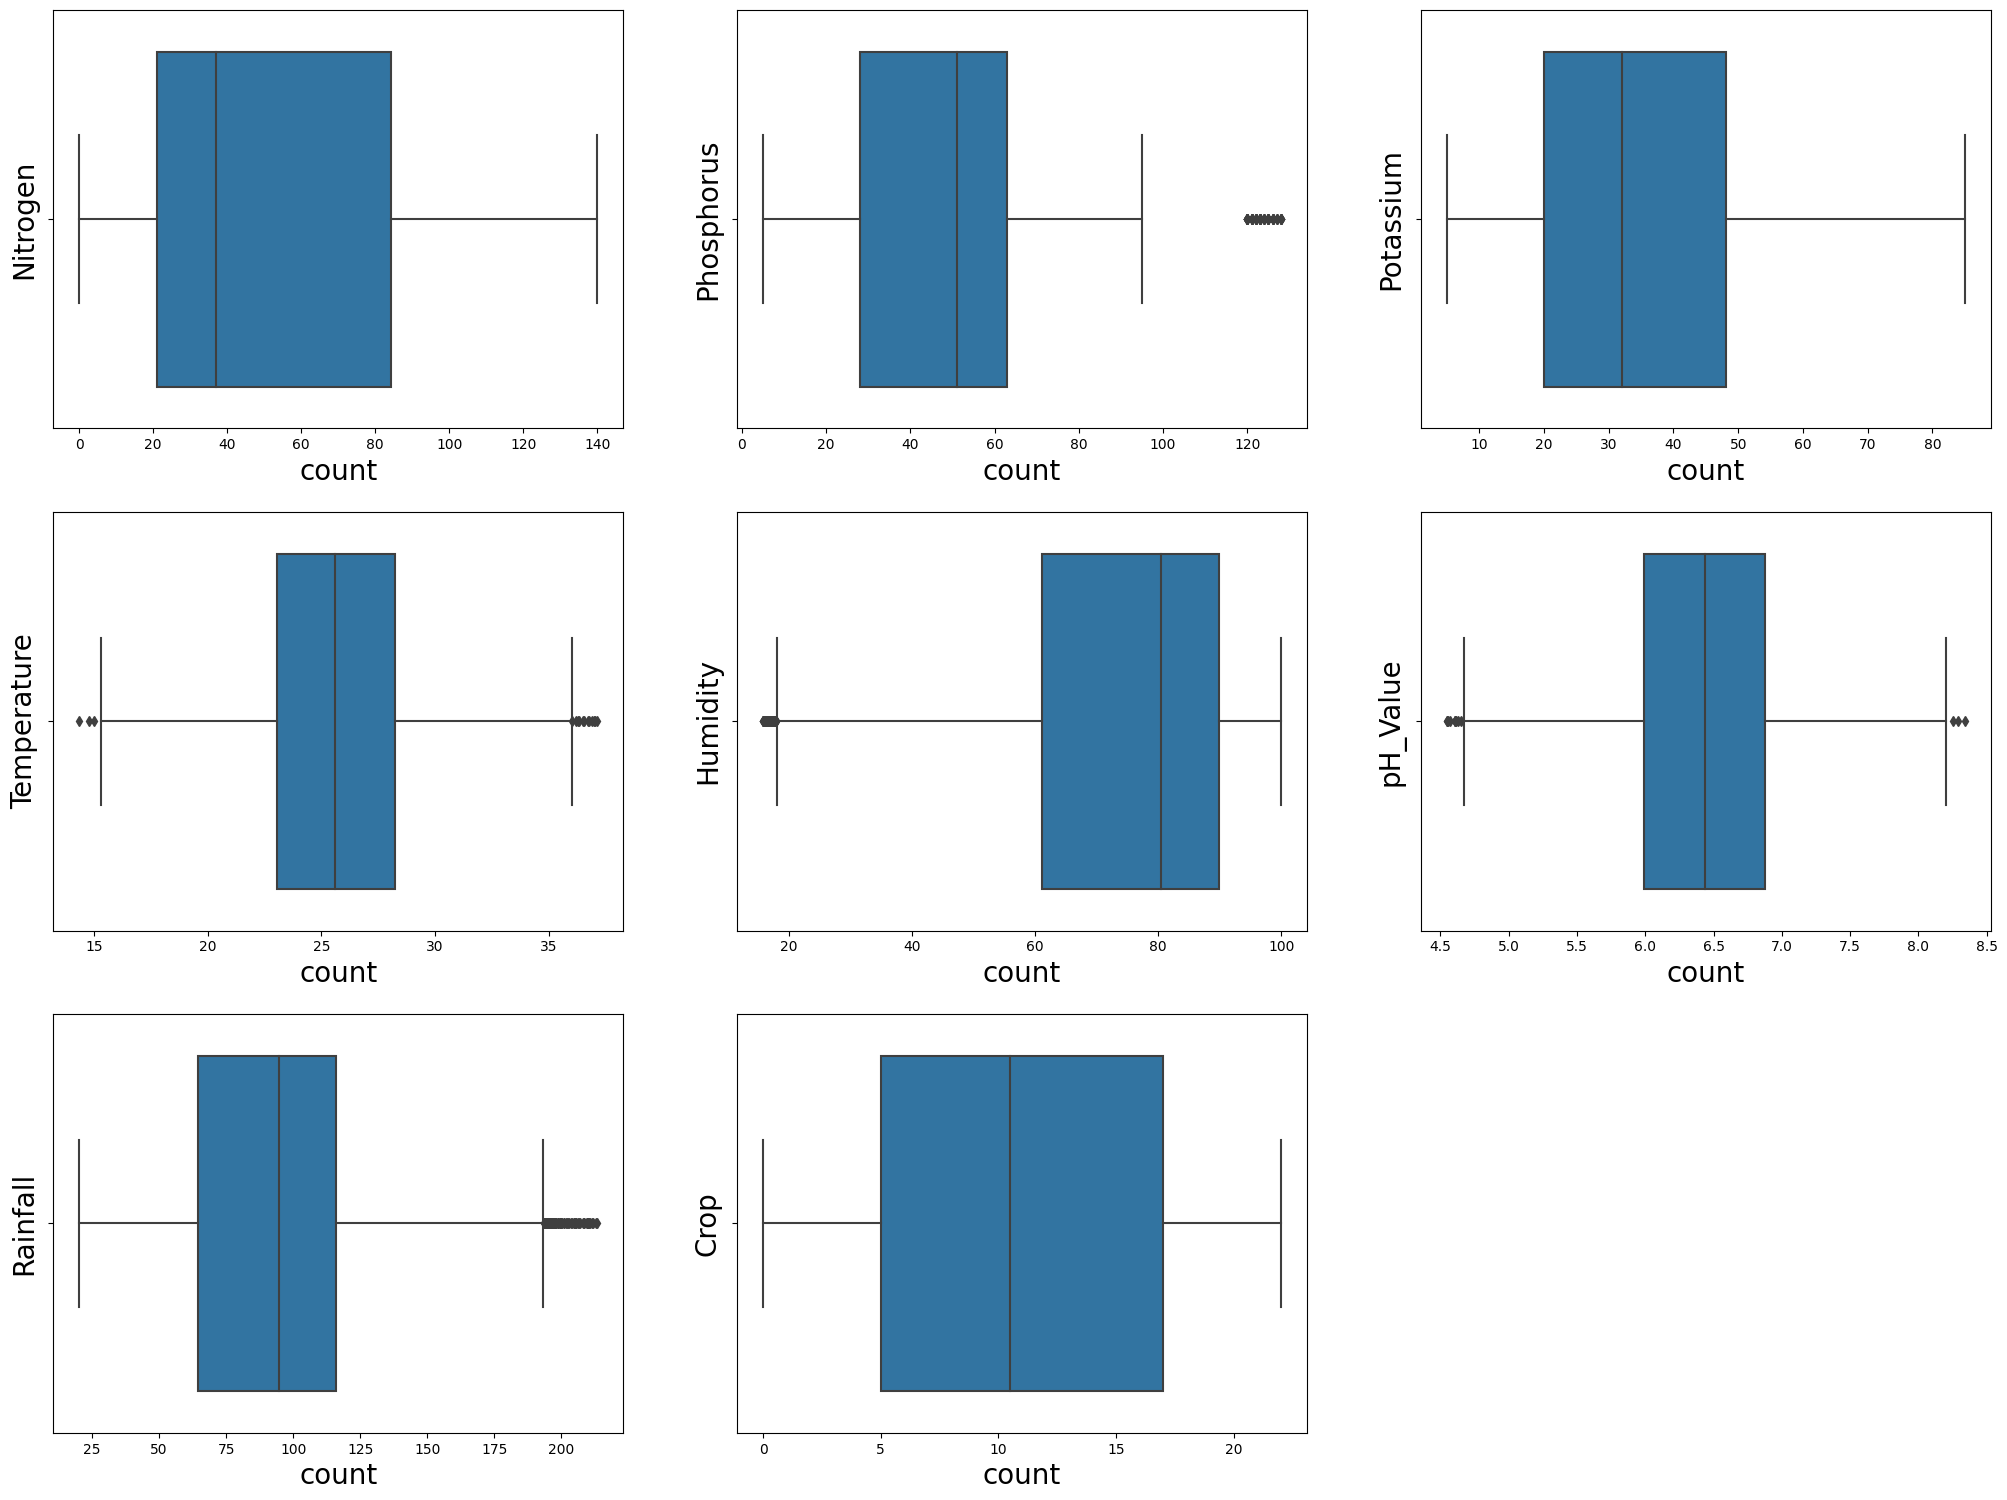

In [21]:
plt.figure(figsize=(25,25),facecolor='white')
pltnumber=1

for col in data:
    if pltnumber<=12:
        ax = plt.subplot(4,3,pltnumber)
        sns.boxplot(x=data[col])
        plt.xlabel('count',fontsize=20)
        plt.ylabel(col,fontsize=20)
    pltnumber+=1
plt.show()

# Scaling of Data

In [22]:
from sklearn.preprocessing import MinMaxScaler
scale = MinMaxScaler()
df = scale.fit_transform(data)

In [23]:
df

array([[0.64285714, 0.30081301, 0.475     , ..., 0.51569696, 0.94604797,
        0.        ],
       [0.60714286, 0.43089431, 0.45      , ..., 0.65674089, 0.43103608,
        0.        ],
       [0.42857143, 0.40650407, 0.4875    , ..., 0.86816028, 0.43103608,
        0.        ],
       ...,
       [0.84285714, 0.22764228, 0.3125    , ..., 0.47869645, 0.79272935,
        1.        ],
       [0.83571429, 0.2195122 , 0.3625    , ..., 0.58312233, 0.55380218,
        1.        ],
       [0.74285714, 0.10569106, 0.3125    , ..., 0.58866804, 0.62505311,
        1.        ]])

In [24]:
data.columns

Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall', 'Crop'],
      dtype='object')

In [25]:
df1 = pd.DataFrame(df,columns=['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall', 'Crop'])

In [26]:
df1

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,0.642857,0.300813,0.4750,0.286836,0.786537,0.515697,0.946048,0.0
1,0.607143,0.430894,0.4500,0.325922,0.766554,0.656741,0.431036,0.0
2,0.428571,0.406504,0.4875,0.380072,0.790313,0.868160,0.431036,0.0
3,0.528571,0.243902,0.4375,0.533072,0.764639,0.641534,0.431036,0.0
4,0.557143,0.300813,0.4625,0.253943,0.781813,0.812352,0.431036,0.0
...,...,...,...,...,...,...,...,...
2195,0.764286,0.235772,0.3375,0.545515,0.601446,0.588729,0.815778,1.0
2196,0.707143,0.081301,0.2750,0.573708,0.485366,0.406032,0.557682,1.0
2197,0.842857,0.227642,0.3125,0.429542,0.611085,0.478696,0.792729,1.0
2198,0.835714,0.219512,0.3625,0.523476,0.431832,0.583122,0.553802,1.0


<Axes: >

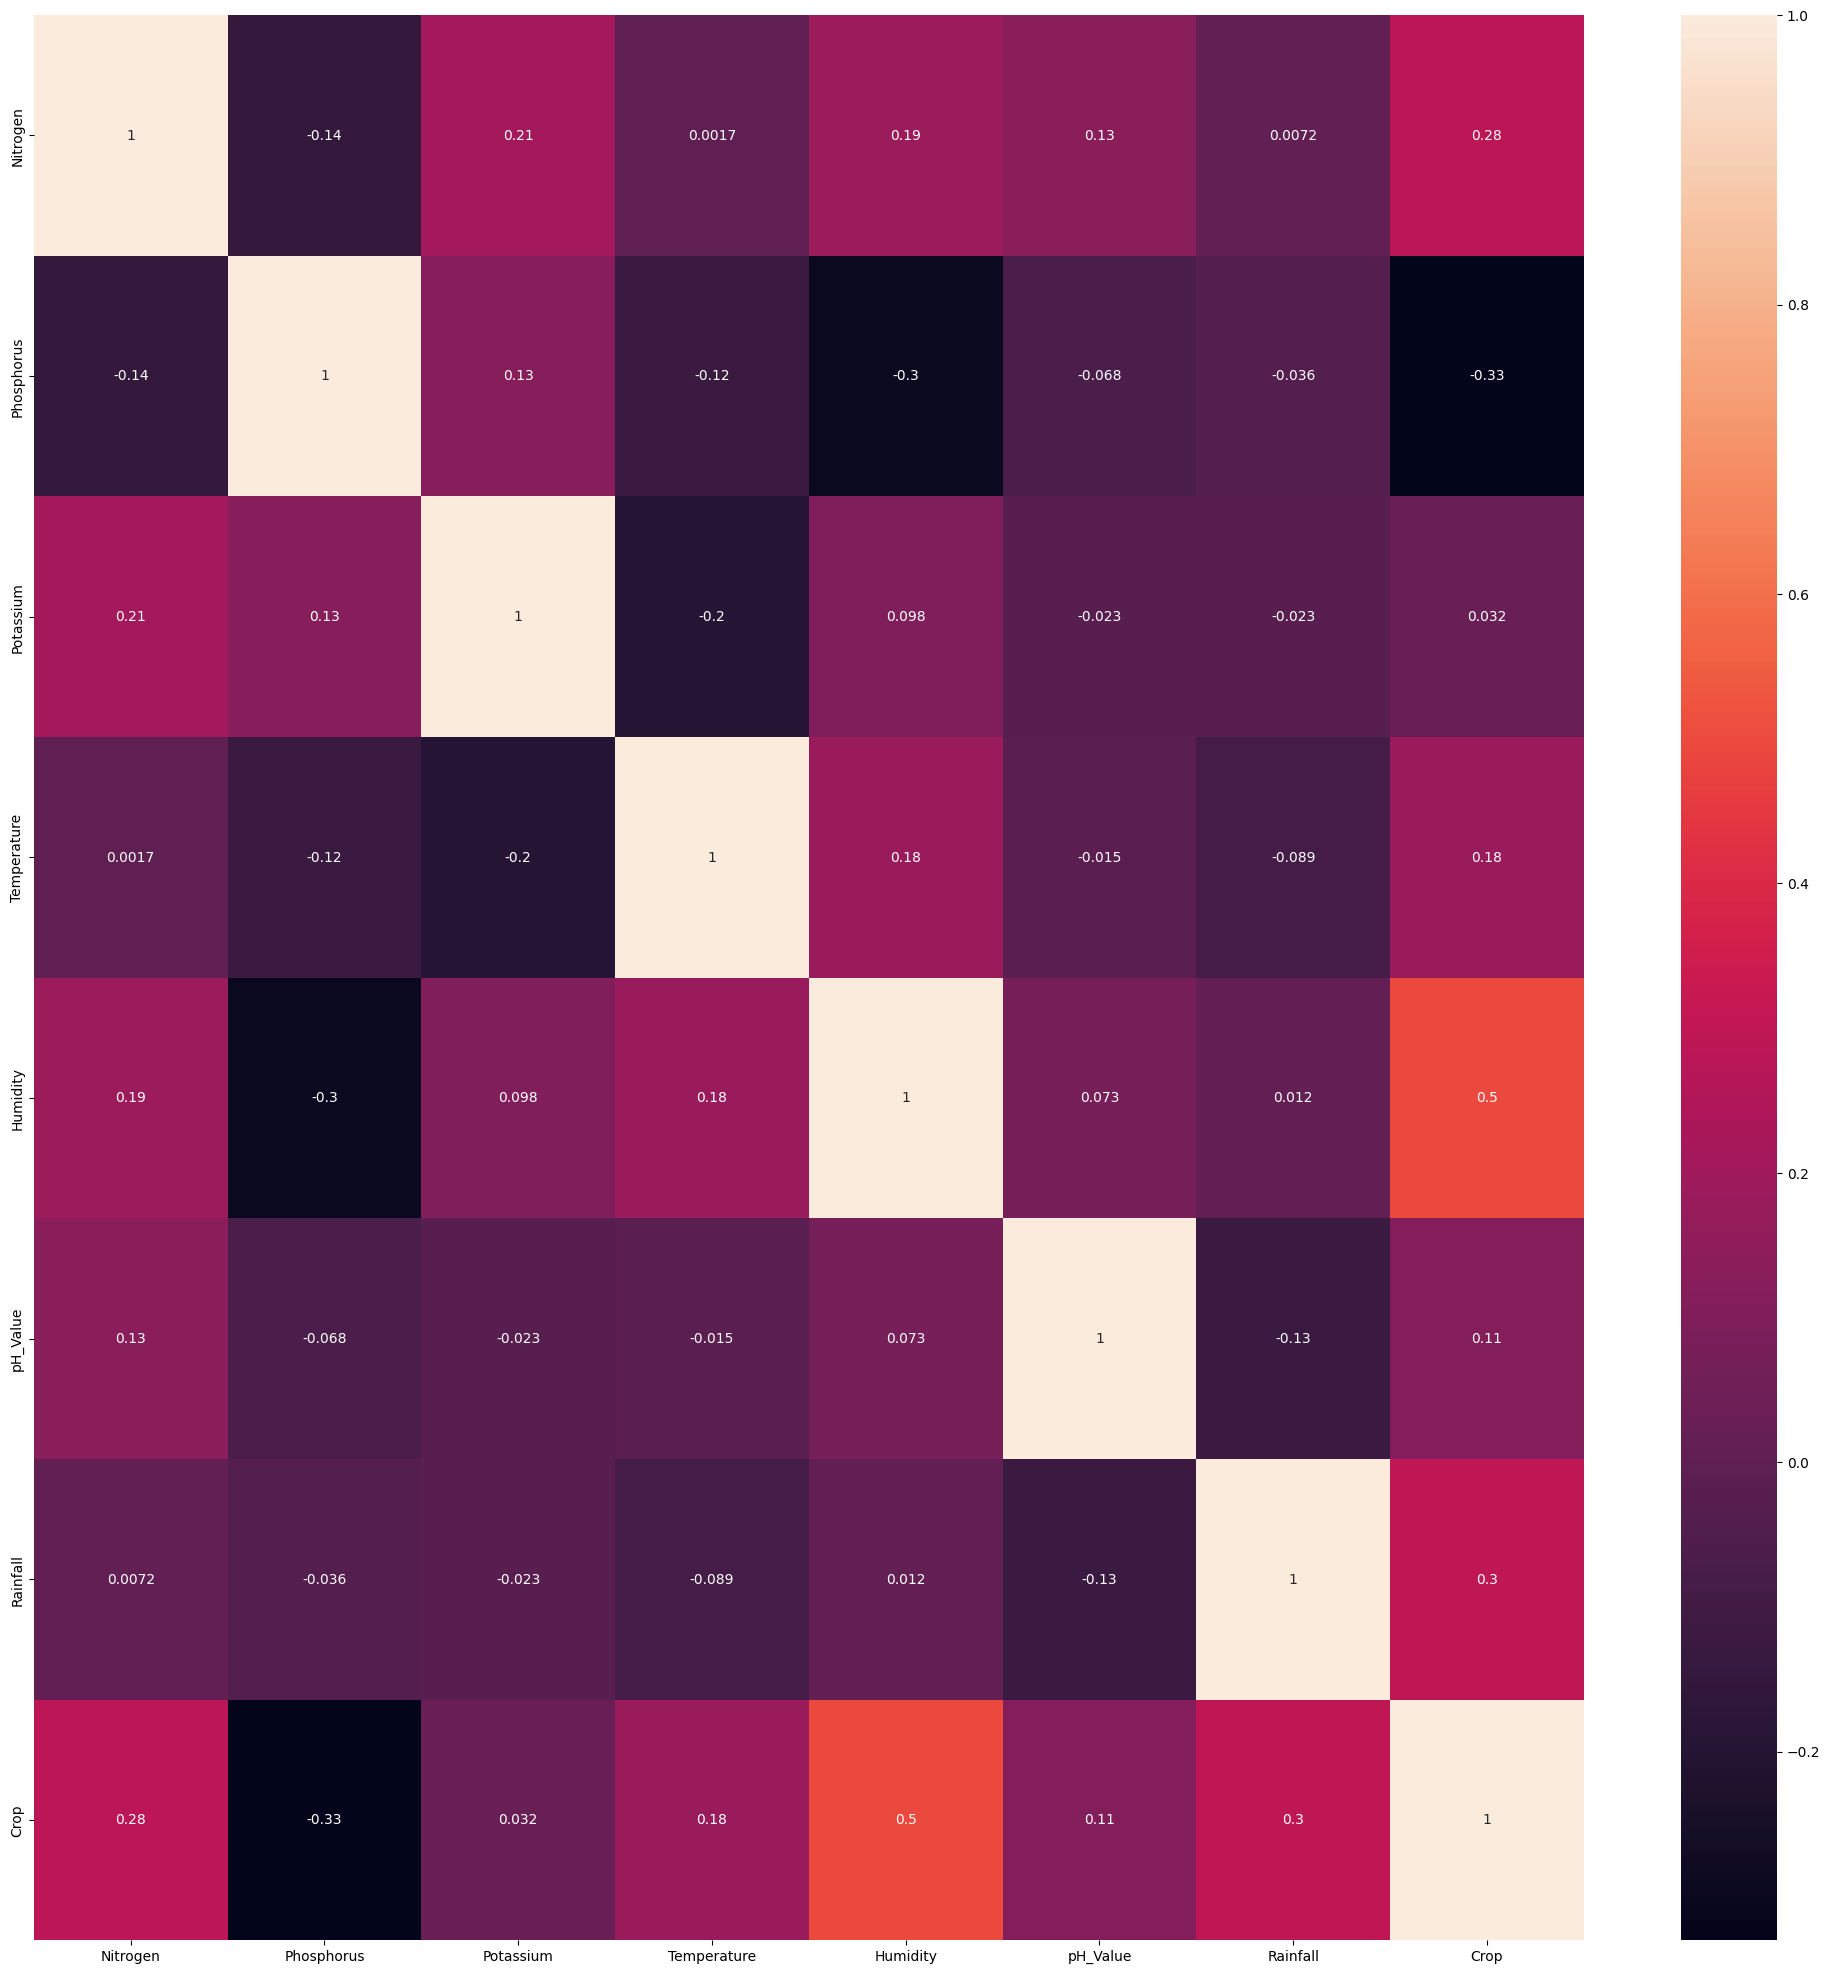

In [27]:
plt.figure(figsize=(25,25),facecolor='white')
sns.heatmap(df1.corr(),annot=True)

# Model Creation

In [28]:
x = df1.drop('Crop',axis=1)
y = data['Crop']

In [29]:
# Trainig Mode; Using train_test_split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42) 

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


from sklearn.datasets import make_classification

# Create a dataset with 1000 samples, 20 features, and 21 classes
x, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5,
    n_classes=21, n_clusters_per_class=1, random_state=42)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(x_train, y_train)

# Predict on the test set
y_pred = rf_classifier.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)


Accuracy: 0.495
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.40      0.42        10
           1       0.36      0.56      0.43         9
           2       0.31      0.50      0.38         8
           3       0.62      0.62      0.62         8
           4       0.36      0.56      0.43         9
           5       0.80      0.36      0.50        11
           6       0.38      0.83      0.53         6
           7       0.44      0.57      0.50         7
           8       0.17      0.12      0.14         8
           9       0.50      0.36      0.42        11
          10       0.60      0.82      0.69        11
          11       0.80      0.36      0.50        11
          12       0.71      0.36      0.48        14
          13       0.44      0.80      0.57         5
          14       0.43      0.38      0.40         8
          15       0.46      0.60      0.52        10
          16       0.50      0.23      0.3

# Adding Hyper Parameters

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification

# Create a dataset with 1000 samples, 20 features, and 21 classes
x, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5,
    n_classes=21, n_clusters_per_class=1, random_state=42)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2)

# Train the model with GridSearchCV
grid_search.fit(x_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_rf_classifier = grid_search.best_estimator_

# Predict on the test set with the best model
y_pred = best_rf_classifier.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Best Parameters: {best_params}")
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 0.515
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.40      0.42        10
           1       0.42      0.56      0.48         9
           2       0.31      0.50      0.38         8
           3       0.62      0.62      0.62         8
           4       0.33      0.56      0.42         9
           5       0.78      0.64      0.70        11
           6       0.33      0.83      0.48         6
           7       0.57      0.57      0.57         7
           8       0.38      0.38      0.38         8
           9       0.50      0.45      0.48        11
          10       0.58      0.64      0.61        11
          11       1.00      0.55      0.71        11
          12       0.75      0.43      0.55        14
          13     